In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [28]:
data = pd.read_csv('data/cleaned_chargingdata.csv')

In [31]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75329 entries, 0 to 75328
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0.1        75329 non-null  int64  
 1   Unnamed: 0          75329 non-null  int64  
 2   id                  75329 non-null  string 
 3   connectionTime      75329 non-null  object 
 4   disconnectTime      75329 non-null  object 
 5   doneChargingTime    75329 non-null  object 
 6   kWhDelivered        75329 non-null  float64
 7   sessionID           75329 non-null  object 
 8   siteID              75329 non-null  int64  
 9   spaceID             75329 non-null  object 
 10  stationID           75329 non-null  object 
 11  timezone            75329 non-null  object 
 12  userID              58975 non-null  float64
 13  WhPerMile           58975 non-null  float64
 14  kWhRequested        58975 non-null  float64
 15  milesRequested      58975 non-null  float64
 16  minu

In [33]:
data['id'] = data['id'].astype('string')

data['connectionTime'] = pd.to_datetime(data['connectionTime'], errors='coerce')  
data['disconnectTime'] = pd.to_datetime(data['disconnectTime'], errors='coerce')  
data['doneChargingTime'] = pd.to_datetime(data['doneChargingTime'], errors='coerce') 

data['connectionTime'] = data['connectionTime'].dt.tz_convert('America/Los_Angeles')
data['disconnectTime'] = data['disconnectTime'].dt.tz_convert('America/Los_Angeles')
data['doneChargingTime'] = data['doneChargingTime'].dt.tz_convert('America/Los_Angeles')

data['sessionID'] = data['sessionID'].astype('string')
data['siteID'] = data['siteID'].astype('string')
data['spaceID'] = data['spaceID'].astype('string')
data['stationID'] = data['stationID'].astype('string')
data['timezone'] = data['timezone'].astype('string')
data['userID'] = data['userID'].astype('string')

## First KPI is Enegry delivered per Hour WIP

In [34]:
data['hour'] = data['connectionTime'].dt.hour
energy_per_hour = data.groupby('hour')['kWhDelivered'].sum()

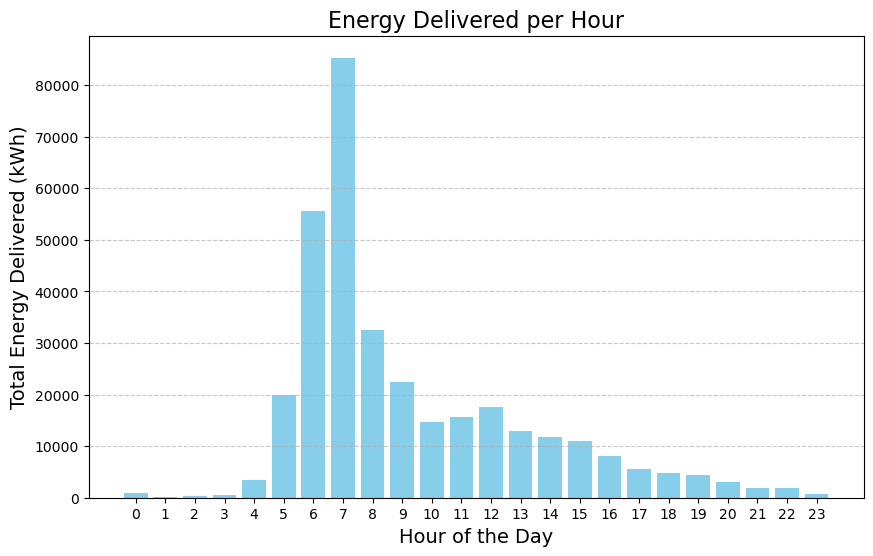

In [35]:
plt.figure(figsize=(10, 6))
plt.bar(energy_per_hour.index, energy_per_hour.values, color='skyblue')
plt.title('Energy Delivered per Hour', fontsize=16)
plt.xlabel('Hour of the Day', fontsize=14)
plt.ylabel('Total Energy Delivered (kWh)', fontsize=14)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Second KPI AVG Session Duration WIP

In [36]:
#data['connectionTime'] = pd.to_datetime(data['connectionTime'])
#data['disconnectTime'] = pd.to_datetime(data['disconnectTime'])

data['sessionDuration'] = (data['disconnectTime'] - data['connectionTime']).dt.total_seconds() / 60

avg_duration_per_hour = data.groupby('hour')['sessionDuration'].mean()

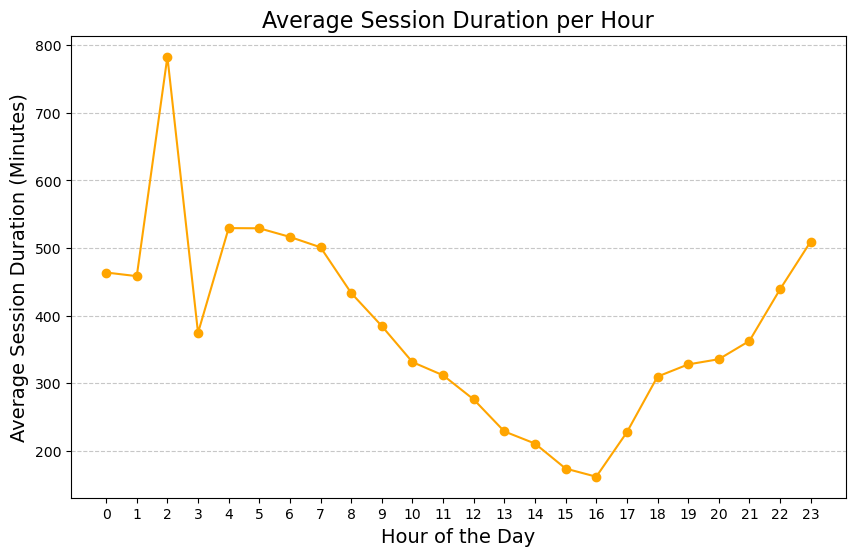

In [37]:
plt.figure(figsize=(10, 6))
plt.plot(avg_duration_per_hour.index, avg_duration_per_hour.values, marker='o', color='orange')
plt.title('Average Session Duration per Hour', fontsize=16)
plt.xlabel('Hour of the Day', fontsize=14)
plt.ylabel('Average Session Duration (Minutes)', fontsize=14)
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Third KPI Utilization Rate WIP

In [38]:
total_chargers = 20  # Replace with the actual number of chargers

time_range = pd.date_range(start=data['connectionTime'].min(), end=data['disconnectTime'].max(), freq='H')
active_sessions_per_hour = {hour: 0 for hour in time_range}

C:\Users\Jan\AppData\Local\Temp\ipykernel_23964\3528405598.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_range = pd.date_range(start=data['connectionTime'].min(), end=data['disconnectTime'].max(), freq='H')


In [39]:
for hour in time_range:
    active_sessions_per_hour[hour] = np.sum(
        (data['connectionTime'] <= hour) & (data['disconnectTime'] > hour)
    )

In [40]:
utilization_data = pd.DataFrame.from_dict(active_sessions_per_hour, orient='index', columns=['activeSessions'])
utilization_data['hour'] = utilization_data.index.hour
utilization_data['utilizationRate'] = (utilization_data['activeSessions'] / total_chargers) * 100


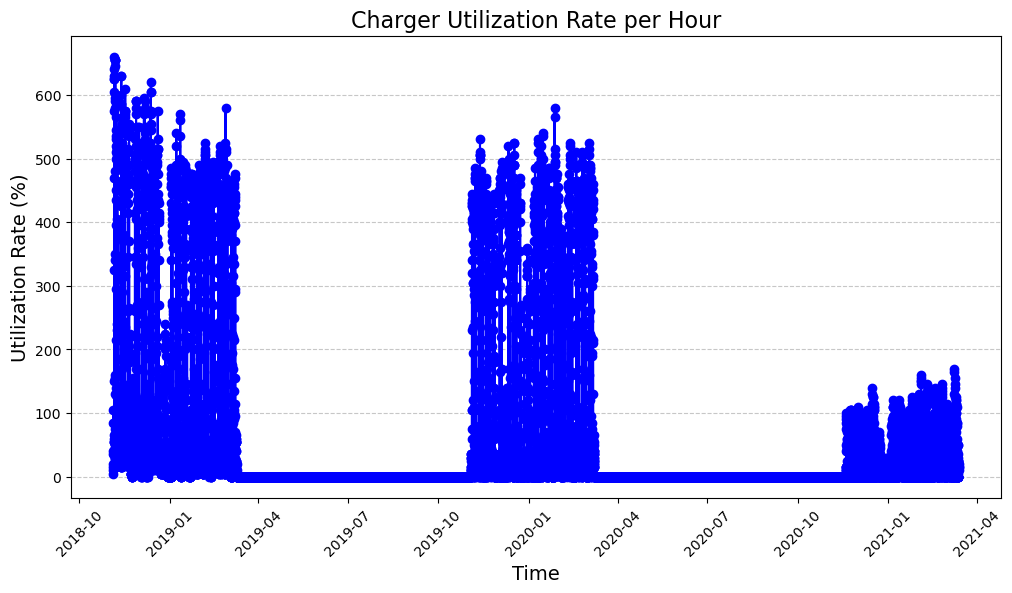

In [41]:
plt.figure(figsize=(12, 6))
plt.plot(utilization_data.index, utilization_data['utilizationRate'], color='blue', marker='o')
plt.title('Charger Utilization Rate per Hour', fontsize=16)
plt.xlabel('Time', fontsize=14)
plt.ylabel('Utilization Rate (%)', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.show()